In [1]:
import sys
sys.executable


'C:\\Program Files\\Python310\\python.exe'

# Crypto Directional ML  
## Notebook 01 — Exploratory Data Analysis (EDA)

**Author:** Eneida Araújo  

This notebook is part of the *Crypto Directional ML* project and focuses on the exploratory analysis of BTC/USDT 4-hour market data.  
The objective is to understand price behavior, return distributions, and volatility dynamics as a foundation for feature engineering and predictive modeling.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 1. Dataset Overview

The dataset contains historical BTC/USDT market data sampled at 4-hour intervals.

It includes:
- Open, high, low, and close prices
- Trading volume
- Number of trades
- Buyer-initiated volume metrics

This structure supports both price-based and liquidity-based exploratory analyses.


In [3]:
# Dataset path
DATA_PATH = "../data/raw/btcusdt_4h_2019_present.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

# Initial data preview
df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2019-01-01 00:00:00,3701.23,3713.00,3675.04,3693.13,2991.923534,2019-01-01 03:59:59.999,1.105024e+07,22720,1623.305261,5.995807e+06,0
1,2019-01-01 04:00:00,3692.32,3726.64,3685.94,3713.83,3373.760399,2019-01-01 07:59:59.999,1.249456e+07,21968,1906.765643,7.061960e+06,0
2,2019-01-01 08:00:00,3714.19,3732.00,3696.14,3707.54,2977.758983,2019-01-01 11:59:59.999,1.105881e+07,20706,1574.891618,5.849649e+06,0
3,2019-01-01 12:00:00,3707.56,3756.94,3666.01,3682.61,3720.118569,2019-01-01 15:59:59.999,1.378055e+07,24464,1967.842057,7.293411e+06,0
4,2019-01-01 16:00:00,3683.00,3701.68,3642.00,3696.73,3248.115975,2019-01-01 19:59:59.999,1.193798e+07,22941,1790.133125,6.579838e+06,0


In [4]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15338 entries, 0 to 15337
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   open_time               15338 non-null  object 
 1   open                    15338 non-null  float64
 2   high                    15338 non-null  float64
 3   low                     15338 non-null  float64
 4   close                   15338 non-null  float64
 5   volume                  15338 non-null  float64
 6   close_time              15338 non-null  object 
 7   quote_asset_volume      15338 non-null  float64
 8   number_of_trades        15338 non-null  int64  
 9   taker_buy_base_volume   15338 non-null  float64
 10  taker_buy_quote_volume  15338 non-null  float64
 11  ignore                  15338 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 1.4+ MB


## 2. Datetime Processing

The `open_time` and `close_time` variables are converted to datetime format to enable proper temporal ordering, rolling-window calculations, and time-based visualizations.


In [5]:
# Time column conversion
df["open_time"] = pd.to_datetime(df["open_time"])
df["close_time"] = pd.to_datetime(df["close_time"])

# Ensure chronological ordering
df = df.sort_values("open_time").reset_index(drop=True)

# Verification
df[["open_time", "close_time"]].head()


,open_time,close_time
0,2019-01-01 00:00:00,2019-01-01 03:59:59.999
1,2019-01-01 04:00:00,2019-01-01 07:59:59.999
2,2019-01-01 08:00:00,2019-01-01 11:59:59.999
3,2019-01-01 12:00:00,2019-01-01 15:59:59.999
4,2019-01-01 16:00:00,2019-01-01 19:59:59.999


In [6]:
# Recheck data types after conversion
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15338 entries, 0 to 15337
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   open_time               15338 non-null  datetime64[ns]
 1   open                    15338 non-null  float64       
 2   high                    15338 non-null  float64       
 3   low                     15338 non-null  float64       
 4   close                   15338 non-null  float64       
 5   volume                  15338 non-null  float64       
 6   close_time              15338 non-null  datetime64[ns]
 7   quote_asset_volume      15338 non-null  float64       
 8   number_of_trades        15338 non-null  int64         
 9   taker_buy_base_volume   15338 non-null  float64       
 10  taker_buy_quote_volume  15338 non-null  float64       
 11  ignore                  15338 non-null  int64         
dtypes: datetime64[ns](2), float64(8), int64(2)
mem

## 3. Logarithmic Returns

Logarithmic returns are computed to stabilize variance and facilitate statistical analysis.
They are widely used in financial modeling due to their time-additive properties and closer alignment with continuous compounding assumptions.


In [7]:
# Logarithmic return
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# Preview of log returns
df[["open_time", "close", "log_return"]].head(10)


,open_time,close,log_return
0,2019-01-01 00:00:00,3693.13,NaN
1,2019-01-01 04:00:00,3713.83,0.005589
2,2019-01-01 08:00:00,3707.54,-0.001695
3,2019-01-01 12:00:00,3682.61,-0.006747
4,2019-01-01 16:00:00,3696.73,0.003827
5,2019-01-01 20:00:00,3797.14,0.026800
6,2019-01-02 00:00:00,3779.98,-0.004529
7,2019-01-02 04:00:00,3771.08,-0.002357
8,2019-01-02 08:00:00,3787.97,0.004469
9,2019-01-02 12:00:00,3801.28,0.003508


In [8]:
# Number of missing values (expected at the first observation)
df["log_return"].isna().sum()

np.int64(1)

## 4. Distribution of Logarithmic Returns

The distribution of logarithmic returns is analyzed to assess deviations from normality, including skewness and heavy tails, which are typical features of financial time series.


In [9]:
df["log_return"].describe()


count    15337.000000
mean         0.000207
std          0.013186
min         -0.229366
25%         -0.004529
50%          0.000218
75%          0.005027
max          0.137577
Name: log_return, dtype: float64

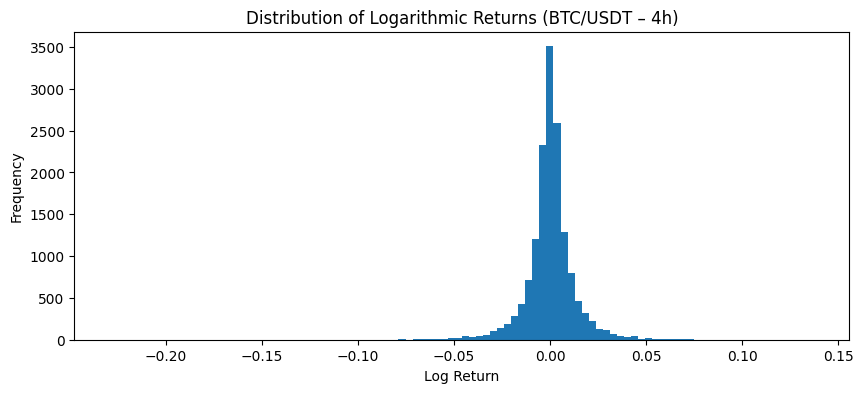

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(df["log_return"].dropna(), bins=100)

plt.title("Distribution of Logarithmic Returns (BTC/USDT – 4h)")
plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.show()


## 5. Volatility Analysis

Rolling volatility is computed to investigate time-varying risk and volatility clustering, a_toggle characteristic of real financial markets.


In [11]:
df["volatility_20"] = df["log_return"].rolling(window=20).std()

df[["open_time", "log_return", "volatility_20"]].tail()


,open_time,log_return,volatility_20
15333,2025-12-31 08:00:00,0.004486,0.008901
15334,2025-12-31 12:00:00,-0.011952,0.009342
15335,2025-12-31 16:00:00,-0.004697,0.009394
15336,2025-12-31 20:00:00,0.001214,0.009399
15337,2026-01-01 00:00:00,0.002254,0.009375


### Volatility Interpretation

The volatility series exhibits clustering, characterized by prolonged periods of low variability interspersed with abrupt volatility spikes.

This behavior violates homoscedasticity assumptions and supports the use of Machine Learning models capable of capturing regime changes and non-linear dynamics.


## 6. Correlation Analysis

A preliminary correlation analysis is conducted among returns, volatility, and trading volume to explore linear dependencies between price dynamics and market activity.


In [12]:
df[["log_return", "volatility_20", "volume"]].corr()


,log_return,volatility_20,volume
log_return,1.000000,-0.003361,-0.011811
volatility_20,-0.003361,1.000000,0.213193
volume,-0.011811,0.213193,1.000000


## 7. Key Findings and Next Steps

The exploratory analysis reveals:
- Non-normal return distributions
- Time-dependent and clustered volatility
- Evidence of regime behavior in price dynamics

These findings justify the adoption of Machine Learning–based approaches in subsequent stages of the project, particularly for feature engineering and directional prediction modeling.


**Interpretation:**  
The weak linear correlation between returns and volatility suggests that risk dynamics are largely time-dependent rather than directly driven by contemporaneous price changes. The positive correlation between volatility and volume indicates increased trading activity during high-risk periods, a well-documented stylized fact in financial markets.
